## 1. Setup

In [1]:
import sys
sys.path.insert(0, '..')

from pathlib import Path

import torch
from IPython.display import Image as IPImage

ROOT        = Path('..')
FIGURES_DIR = ROOT / 'reports' / 'figures'
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Device: {device}')
if device == 'cuda':
    print(f'GPU:  {torch.cuda.get_device_name(0)}')
    print(f'VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')

Device: cuda
GPU:  NVIDIA GeForce RTX 3050 6GB Laptop GPU
VRAM: 6.4 GB


## 2. Model Architecture

In [2]:
from src.model import ConvAutoencoder

model = ConvAutoencoder()
print(model)
print()
print(model.get_model_info())

ConvAutoencoder
Encoder
  Conv2d(  3 ->  32, k=3, s=2, p=1)  224 -> 112
  Conv2d( 32 ->  64, k=3, s=2, p=1)  112 ->  56
  Conv2d( 64 -> 128, k=3, s=2, p=1)   56 ->  28
  Conv2d(128 -> 256, k=3, s=2, p=1)   28 ->  14  [bottleneck]
----------------------------------------------------
Decoder
  ConvT(256 -> 128, k=3, s=2, p=1)   14 ->  28
  ConvT(128 ->  64, k=3, s=2, p=1)   28 ->  56
  ConvT( 64 ->  32, k=3, s=2, p=1)   56 -> 112
  ConvT( 32 ->   3, k=3, s=2, p=1)  112 -> 224  + Sigmoid
  Total params:     777,987
  Trainable params: 777,987
  Bottleneck:       (256, 14, 14)

{'total_params': 777987, 'trainable_params': 777987, 'input_shape': (3, 224, 224), 'bottleneck_shape': (256, 14, 14), 'output_shape': (3, 224, 224)}


## 3. Sanity Check — Forward Pass

In [3]:
from src.dataset import get_dataloaders

loaders = get_dataloaders(ROOT, batch_size=4)
x, _, _ = next(iter(loaders['train']))

model_cpu = ConvAutoencoder()
x_hat, z  = model_cpu(x)

assert x_hat.shape == x.shape, f'Shape mismatch: {x_hat.shape} != {x.shape}'
errors = ConvAutoencoder.reconstruction_error(x, x_hat)

print(f'Input shape:          {tuple(x.shape)}')
print(f'Reconstruction shape: {tuple(x_hat.shape)}')
print(f'Bottleneck shape:     {tuple(z.shape)}')
print(f'Recon error  min={errors.min():.6f}  max={errors.max():.6f}  mean={errors.mean():.6f}')
print('Sanity check passed.')

Input shape:          (4, 3, 224, 224)
Reconstruction shape: (4, 3, 224, 224)
Bottleneck shape:     (4, 256, 14, 14)
Recon error  min=0.129660  max=0.144139  mean=0.137940
Sanity check passed.


## 4. Training

> **Note:** Expected ~30 min on RTX 3050. MLflow tracks all metrics.
> Launch the MLflow UI with `mlflow ui` from the project root after training.

In [4]:
from src.train import train

config = {
    'root_dir':   ROOT,
    'batch_size': 16,
    'lr':         1e-4,
    'epochs':     100,
    'device':     device,
    'patience':   10,
}
train(config)

c:\Users\Yasindu\.conda\envs\aerovision\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
2026/03/14 05:16:09 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/03/14 05:16:09 INFO mlflow.store.db.utils: Updating database tables
2026/03/14 05:16:12 INFO mlflow.tracking.fluent: Experiment with name 'autoencoder-anomaly-detection' does not exist. Creating a new experiment.


Epoch   1/100 | train=0.087900 | val=0.077522 | best=0.077522 *
Epoch   2/100 | train=0.068703 | val=0.060425 | best=0.060425 *
Epoch   3/100 | train=0.058543 | val=0.052385 | best=0.052385 *
Epoch   4/100 | train=0.051314 | val=0.045783 | best=0.045783 *
Epoch   5/100 | train=0.045679 | val=0.040953 | best=0.040953 *
Epoch   6/100 | train=0.041063 | val=0.036615 | best=0.036615 *
Epoch   7/100 | train=0.036937 | val=0.032678 | best=0.032678 *
Epoch   8/100 | train=0.033293 | val=0.029653 | best=0.029653 *
Epoch   9/100 | train=0.030086 | val=0.026590 | best=0.026590 *
Epoch  10/100 | train=0.027104 | val=0.023605 | best=0.023605 *
Epoch  11/100 | train=0.024467 | val=0.021199 | best=0.021199 *
Epoch  12/100 | train=0.022104 | val=0.019243 | best=0.019243 *
Epoch  13/100 | train=0.019881 | val=0.016861 | best=0.016861 *
Epoch  14/100 | train=0.017936 | val=0.015905 | best=0.015905 *
Epoch  15/100 | train=0.016299 | val=0.014328 | best=0.014328 *
Epoch  16/100 | train=0.014662 | val=0.0

## 5. Training Results

Loading: C:\Users\Yasindu\Desktop\Stuff\5.ML Projects\deep-learning-projects\03_autoencoder-anomaly-detection\reports\figures\training_curves.png


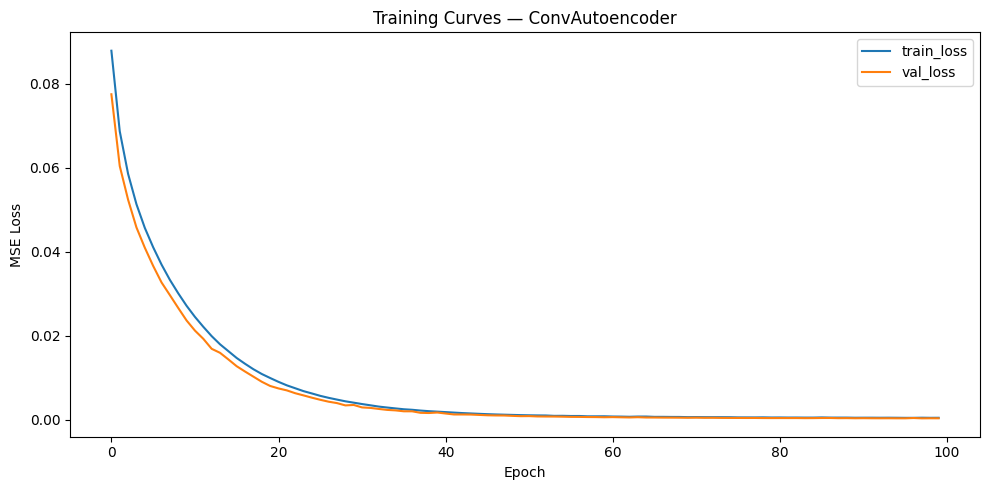

In [5]:
curves_path = FIGURES_DIR / 'training_curves.png'
print(f'Loading: {curves_path.resolve()}')
IPImage(filename=str(curves_path))

## 6. Reconstruction Grid

Loaded checkpoint: C:\Users\Yasindu\Desktop\Stuff\5.ML Projects\deep-learning-projects\03_autoencoder-anomaly-detection\models\best_autoencoder.pt


C:\Users\Yasindu\AppData\Local\Temp\ipykernel_65172\1740376957.py:8: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(checkpoint_path, map_loca

Saved: C:\Users\Yasindu\Desktop\Stuff\5.ML Projects\deep-learning-projects\03_autoencoder-anomaly-detection\reports\figures\reconstruction_comparison.png


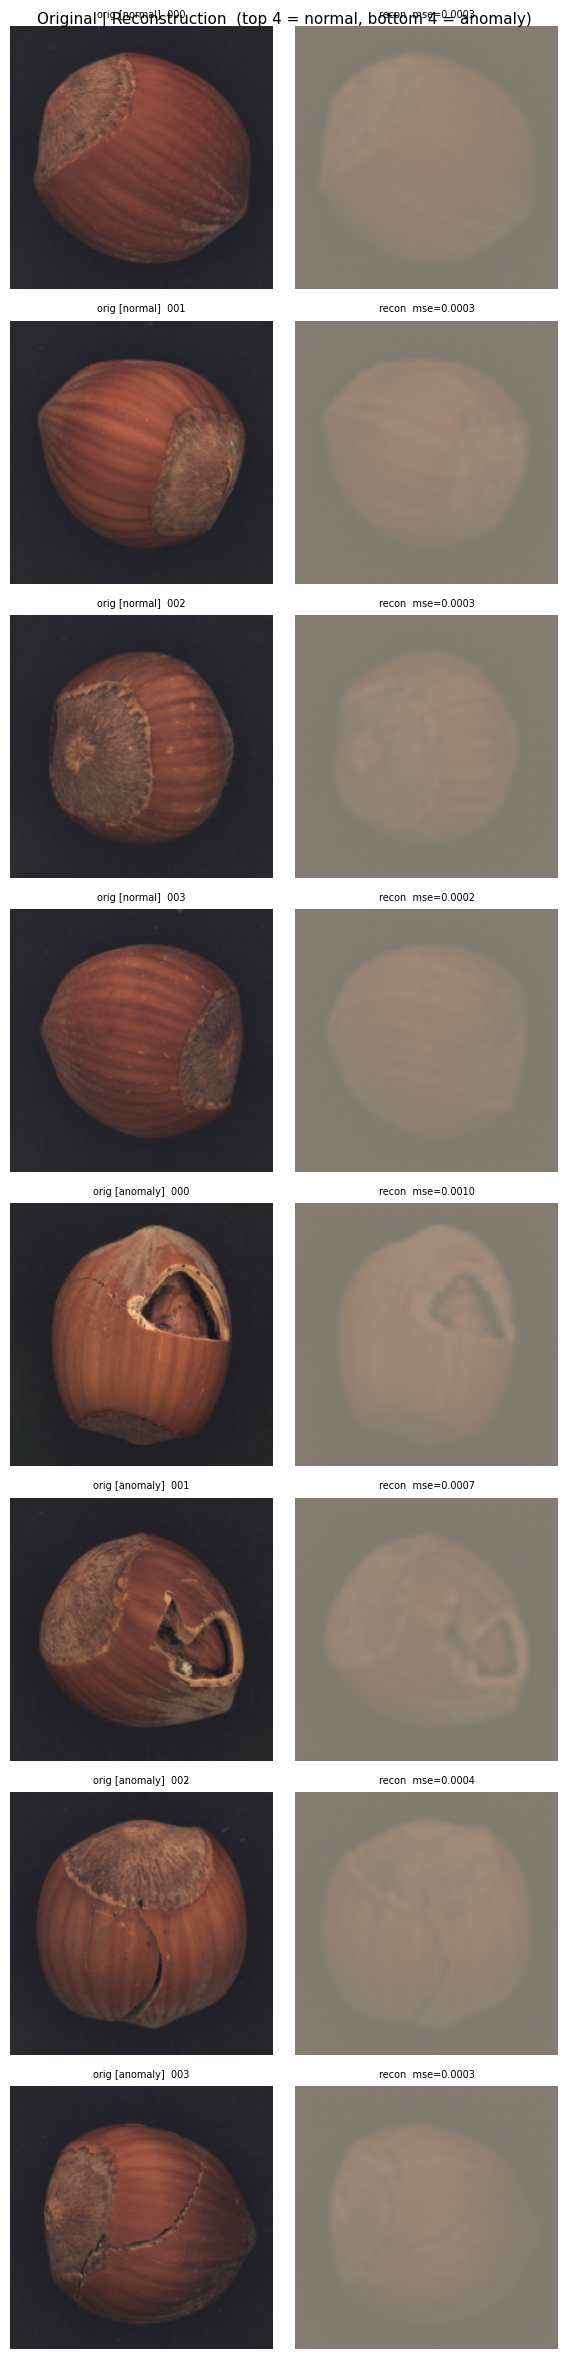

In [6]:
import matplotlib.pyplot as plt
import torch

from src.dataset import MVTecDataset

# Load best checkpoint into model
checkpoint_path = ROOT / 'models' / 'best_autoencoder.pt'
model.load_state_dict(torch.load(checkpoint_path, map_location=device))
model.to(device).eval()
print(f'Loaded checkpoint: {checkpoint_path.resolve()}')

# Denorm: ImageNet-normalised tensor -> HWC numpy in [0, 1]
_mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
_std  = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
def denorm(t):
    return (t.cpu() * _std + _mean).clamp(0, 1).permute(1, 2, 0).numpy()

# Collect 4 normal + 4 anomalous from test split
test_ds      = MVTecDataset(ROOT, split='test')
normal_idxs  = [i for i, (_, lbl) in enumerate(test_ds.samples) if lbl == 0][:4]
anomaly_idxs = [i for i, (_, lbl) in enumerate(test_ds.samples) if lbl == 1][:4]

# 8 rows x 2 cols: original | reconstruction
fig, axes = plt.subplots(8, 2, figsize=(6, 24))
for row, idx in enumerate(normal_idxs + anomaly_idxs):
    x_s, lbl, fname = test_ds[idx]
    with torch.no_grad():
        x_hat_s, _ = model(x_s.unsqueeze(0).to(device))
    tag = 'normal' if lbl == 0 else 'anomaly'
    err = ConvAutoencoder.reconstruction_error(x_s.unsqueeze(0), x_hat_s.cpu()).item()

    axes[row, 0].imshow(denorm(x_s))
    axes[row, 0].set_title(f'orig [{tag}]  {Path(fname).stem}', fontsize=7)
    axes[row, 0].axis('off')

    axes[row, 1].imshow(denorm(x_hat_s.squeeze(0)))
    axes[row, 1].set_title(f'recon  mse={err:.4f}', fontsize=7)
    axes[row, 1].axis('off')

plt.suptitle('Original | Reconstruction  (top 4 = normal, bottom 4 = anomaly)', fontsize=11)
plt.tight_layout()
out_path = FIGURES_DIR / 'reconstruction_comparison.png'
fig.savefig(out_path, bbox_inches='tight')
print(f'Saved: {out_path.resolve()}')
plt.show()